In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail")

print("Path to dataset files:", path)
df = pd.read_csv(path + '/' + os.listdir(path)[0], encoding='latin1')
df.shape

Using Colab cache for faster access to the 'online-retail' dataset.
Path to dataset files: /kaggle/input/online-retail


(541909, 8)

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# 주문 가격 피쳐 생성
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
# 'InvoiceDate' 컬럼을 이용하여 주중과 주말을 구분
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# 'InvoiceDate' 컬럼 이용하여 판매 월 추출
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"].astype(str))
df["InvoiceMonth"] = df["InvoiceDate"].dt.month

## 1. 모집단과 표본 집단의 TotalPrice를 비교해 주세요.

* 데이터셋에서 무작위로 1000개의 표본을 추출하세요.
* 추출된 표본과 전체 데이터셋의 'TotalPrice'에 대해 평균과 표준편차를 비교해주세요.  
* 중심극한정리를 사용해 모집단과 표본의 차이를 설명해주세요.

In [ ]:
# 데이터셋에서 무작위로 1000개의 표본을 추출합니다.
sample_df = df.sample(n=1000, random_state=42)
sample_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,InvoiceMonth
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom,20.40,2,6
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom,27.80,4,5
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom,2.60,3,4
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom,5.85,2,11
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom,19.90,3,3
...,...,...,...,...,...,...,...,...,...,...,...
43603,540098,21977,PACK OF 60 PINK PAISLEY CAKE CASES,1,2011-01-04 15:50:00,0.55,16241.0,United Kingdom,0.55,1,1
421387,572964,22175,PINK OWL SOFT TOY,6,2011-10-27 10:41:00,2.95,12630.0,Finland,17.70,3,10
61634,541434,C2,CARRIAGE,1,2011-01-18 10:22:00,50.00,14911.0,EIRE,50.00,1,1
357609,568101,22950,36 DOILIES VINTAGE CHRISTMAS,24,2011-09-23 15:21:00,1.45,15978.0,United Kingdom,34.80,4,9


In [ ]:
# 표본의 평균과 표준편차
sample_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,DayOfWeek,InvoiceMonth
count,1000.000000,1000,1000.000000,750.000000,1000.000000,1000.000000,1000.000000
mean,7.998000,2011-07-02 12:50:40.200000,3.591080,15225.790667,16.832070,2.345000,7.446000
min,-1350.000000,2010-12-01 12:49:00,0.000000,12353.000000,-222.750000,0.000000,1.000000
25%,1.000000,2011-03-24 06:14:45,1.250000,13695.500000,3.750000,1.000000,4.000000
50%,3.000000,2011-07-14 15:37:00,2.080000,15050.500000,9.615000,2.000000,8.000000
75%,10.000000,2011-10-19 14:00:45,4.130000,16763.250000,17.700000,3.250000,11.000000
max,1000.000000,2011-12-09 10:26:00,222.750000,18283.000000,1790.000000,6.000000,12.000000
std,59.255592,NaN,8.387847,1760.933908,64.467328,1.799225,3.593605


In [128]:
# 전체데이터의 평균과 표준편차 - 표본의 평균과 표준편차 = 차이계산
pop_mean = df['TotalPrice'].mean()
pop_std = df['TotalPrice'].std()
sample_df_mean = sample_df['TotalPrice'].mean()
sample_df_std =  sample_df['TotalPrice'].std()

# 출력
print(f"모집단 평균: {pop_mean:.2f}, 모집단 표준편차: {pop_std:.2f}")
print(f"표본 평균: {sample_df_mean:.2f}, 표본 표준편차: {sample_df_std:.2f}")
print(f"모집단과 표본의 차이: {pop_mean - sample_df_mean:.2f}")

# 표준오차 계산: 모집단 표준편차 / sqrt(표본의 수)
se = pop_std / np.sqrt(1000)
# 표본 평균의 z-score
z_sample = (sample_df_mean - pop_mean) / se
print(f"표본 평균의 z-score: {z_sample:.2f}")

모집단 평균: 17.99, 모집단 표준편차: 378.81
표본 평균: 16.83, 표본 표준편차: 64.47
모집단과 표본의 차이: 1.16
표본 평균의 z-score: -0.10


전체 데이터는 이상치로 인해 표준편차: 378.81라는 수치로 데이터가 광범위하게 분포되어있는데 중심극한정리에 따라 1000개라는 충분히 큰 표본을 추출하여 표본의 평균이 모집단의 평균과 매우 유사하다라는 결과를 확인 할 수 있었습니다. 즉 표본이 전체 데이터를 잘 대표하고있습니다.

## 2. 주문이 가장 많은 상위 두 국가의 'TotalPrice' 평균에 차이가 있는지 검증하세요.

* 'Country' 변수를 바탕으로 주문이 가장 많은 상위 두 국가를 찾으세요.
* 독립표본 t-검정을 사용하여 두 국가 간 'TotalPrice' 평균의 차이가 통계적으로 유의미한지 검증하세요.  
* t-통계량과 p-값을 해석하여 결과를 설명하고, 1종 오류와 2종 오류의 개념을 적용하여 설명해주세요.

In [ ]:
# 주문이 가장 많은 상위 2개 국가 찾기
from scipy import stats

vip_country = df['Country'].value_counts().head(2).index.tolist()
print(f"주문이 가장 많은 상위 두 국가: {vip_country}")
country_1 = vip_country[0]
country_2 = vip_country[1]

# 두 국가의'TotalPrice'추출
group_1 = df[df['Country'] == country_1]['TotalPrice']
group_2 = df[df['Country'] == country_2]['TotalPrice']

# t 검정
t_stat, p_val = stats.ttest_ind(group_1, group_2)

print(f"상위 1위:{country_1}, 상위 2위:{country_2}")
print(f"{country_1} 평균: {group_1.mean():.2f}")
print(f"{country_2} 평균: {group_2.mean():.2f}")
print(f"t 통계량:{t_stat:.4f}")
print(f"p-값(p-value): {p_val:.4f}")

주문이 가장 많은 상위 두 국가: ['United Kingdom', 'Germany']
상위 1위:United Kingdom, 상위 2위:Germany
United Kingdom 평균: 16.53
Germany 평균: 23.35
t 통계량:-1.6839
p-값(p-value): 0.0922


t통계량은 두 집단의 평균이 표준 오차에 비해 얼마나 떨어져있는지 보여주는데 결과값 절대값이 2보다 작은 수치로 두 집단간의 차이가 우연히 발생했을 가능성이 높습니다. 즉 통계적으로 유의미하다고 보기 어렵습니다.
p-value값은 통상적으로 쓰이는 유의확률 0.05보다 크므로'유의미한 차이가 없다'라는 귀무가설을 기각하지 못했습니다.

1종 오류 : 귀무가설이 참인데도 기각하는 것 (차이가 없는데 있다고 판단)
2종 오류 : 대립가설이 참인데도 귀무가설을 기각하지 못하는것 (차이가 있는데 없다고 판단)
이 결과로 관찰 가능한 오류는 2종오류입니다.

## 3. 주중, 주말에 따라서 발생하는 UnitPrice의 분포가 달라지는지 확인하세요.

* 주중의 'UnitPrice'와 주말의 'UnitPrice'의 분포를 분석하기 위해 데이터의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수를 계산하세요.  
* 상자수염그림과 히스토그램을 그려 시각화를 통해 분포를 확인하고 데이터의 분포에 대해 설명해주세요.

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,InvoiceMonth,Daytype
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2,12,Weekday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12,Weekday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2,12,Weekday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12,Weekday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12,Weekday


In [ ]:
# 평일(0~4)과 주말(5~6) 구분 컬럼 생성
df['Daytype'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 주중의 'UnitPrice'와 주말의 'UnitPrice'의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수
stats_Daytype =df.groupby('Daytype')['UnitPrice'].agg(['mean', 'median', 'std', 'var'])
# print(stats_Daytype)

# 25%, 50%, 75% 지점의 값(분위수)
quantiles = df.groupby('Daytype')['UnitPrice'].quantile([0.25, 0.5, 0.75]).unstack()
# print(quantiles)

# 결과
report_stats = pd.concat([stats_Daytype, quantiles], axis=1)
print(report_stats)

             mean  median         std           var  quantile  0.25   0.5  \
Daytype                                                                     
Weekday  4.843425    2.10  103.032058  10615.604927      2.10  1.25  2.10   
Weekend  2.887824    1.85    7.959497     63.353599      1.85  1.25  1.85   

         0.75  
Daytype        
Weekday  4.13  
Weekend  3.75  


<Axes: xlabel='Daytype', ylabel='UnitPrice'>

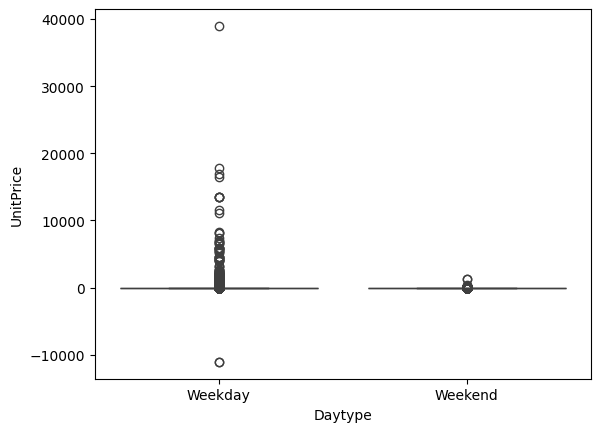

In [ ]:
# # 상자수염 그리기_ 실패_데이터 이상치들로 온전한 박스모양이 구현되지 않았음.
# sns.boxplot(x='Daytype', y='UnitPrice', data=df)

(0.0, 20.0)

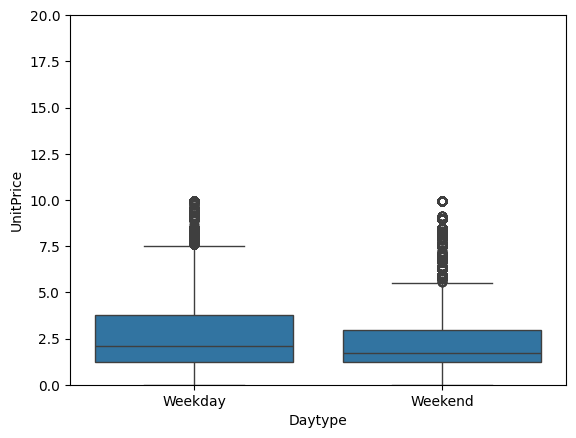

In [ ]:
# UnitPrice 즉 y축의 범위를 0-20으로 제한하여 시각화
sns.boxplot(x='Daytype', y='UnitPrice', data=df_plot)
plt.ylim(0, 20)

<Axes: xlabel='UnitPrice', ylabel='Count'>

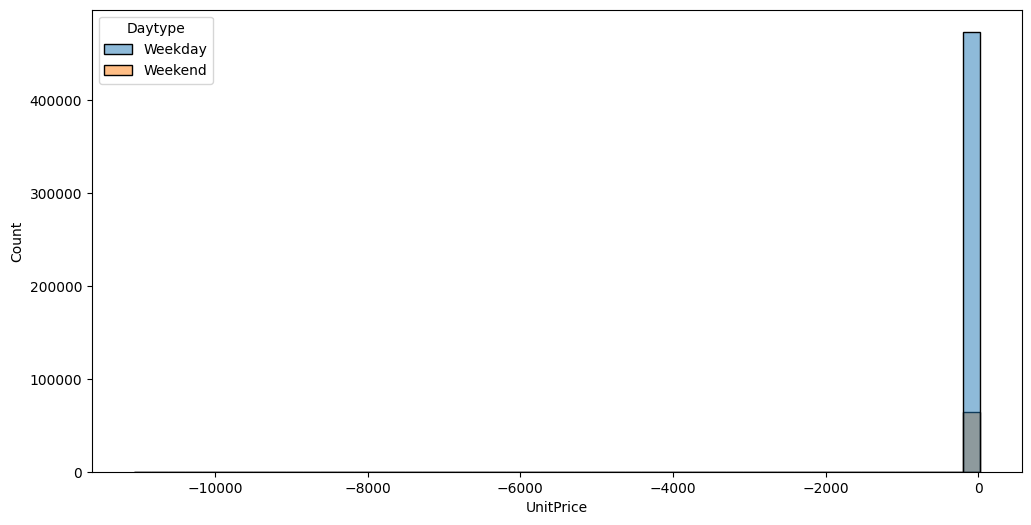

In [ ]:
# # 히스토그램
# df_hist = df[df['UnitPrice'] <= 20]
# plt.figure(figsize=(12, 6))
# sns.histplot(data=df_hist, x='UnitPrice', hue='Daytype', bins=50)

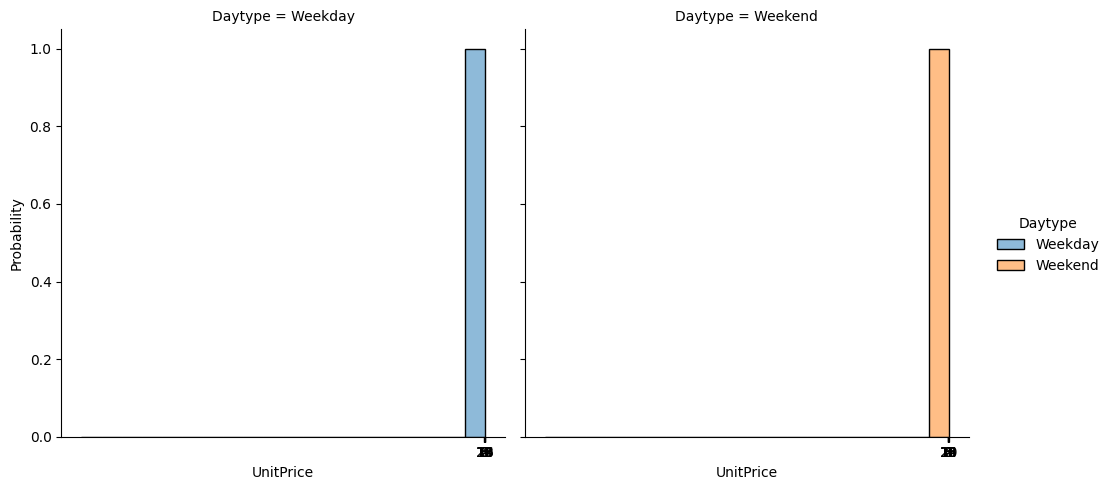

In [ ]:
# # 요일에 따른 상품가격 차이 히스토그램
# df_final = df[df['UnitPrice'] <= 20].copy()

# sns.displot(data=df_final, x='UnitPrice', col='Daytype', hue='Daytype',
#            stat='probability', common_norm=False, bins=20)
# plt.xticks(range(0, 21, 2))
# plt.show()

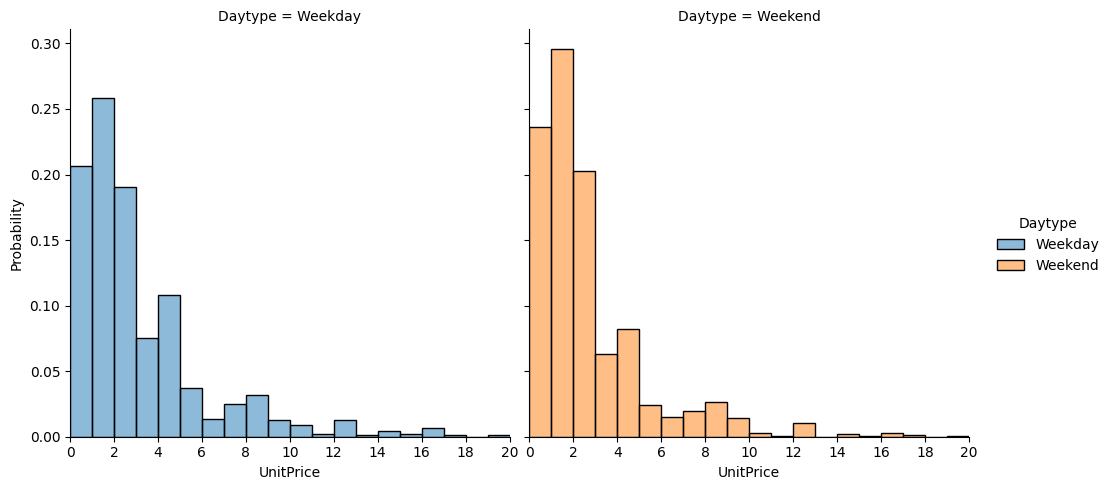

In [115]:
# 0보다 크고 20보다 작은 데이터만 추출 (음수와 0원 제거)
df_final = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 20)].copy()
h = sns.displot(data=df_final, x='UnitPrice', col='Daytype', hue='Daytype',
                kind='hist', stat='probability', common_norm=False, bins=20)
h.set(xticks=range(0, 21, 2), xlim=(0, 20))

In [ ]:
print(df_final['UnitPrice'].value_counts().head())
print("Unique values count:", df_final['UnitPrice'].nunique())

UnitPrice
1.25    50496
1.65    38181
0.85    28497
2.95    27768
0.42    24533
Name: count, dtype: int64
Unique values count: 560


평일과 주말 모두 중간값은 비슷하나 평균값이 중간값보다 높게 나타납니다. 일부의 이상치 즉 고가 상품이 평균을 높이는 우측편향이 발생하였습니다. 평일의 표준편차와 분산이 주말보다 크게 나타남을 수치로 확인 할 수 있었고 평일에 거래량이 더 많기 때문에 가격의 폭이 넓음을 알 수 있습니다.

Boxplot
이상치를 제외한 박스만 보았을때 평일과 주말의 박스 위치가 거의 흡사하다고 판단됩니다. 이것은 요일의 구분 없이 핵심 가격대가 동일함을 알 수 있습니다.

Histogram
음수의 이상치를 제거한 뒤 0-20달러로 범위를 제한 후 요일과 상관없이 1-5 달러에 막대가 집중된 전형적인 우측편향 분포가 관찰되었습니다.

#회고
4번에서 결측치와 이상치를 다루려 최대한 제거하지않는 모든 방법들을 찾아 보았으나 막대 그래프가 박스플롯의 형태로 출력되거나 모든 데이터가 한쪽 끝에만 우뚝 서있는 모습 등 시각화한 목적과 의미를 상실한 결과들만 얻게되었습니다.
다시금 df.info와 value_count를 통해 데이터 타입과 범위를 확인 후 왜곡을 유발하는 지점을 찾고 이상치를 제외,stat='probability'나 xlim 등 그래프의 스케일 처리를 하였습니다. 전처리와 축을 설정하는것이 얼마나 중요한지 다시금 알게되었습니다.

## 4. 상품의 단가와 판매 국가, 판매 날짜을 이용해 판매 수량을 예측하는 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* 변수를 다음과 같이 설정하여 다중 선형 회귀 분석을 진행하세요.
    * 종속변수: 판매 수량(`Quantity`)
    * 독립변수: 상품 단가(`UnitPrice`), 판매 국가(`Country`), 판매 요일(`DayOfWeek`), 판매 월( `InvoiceMonth`)   
* 회귀계수와 결정계수를 활용하여 회귀 분석 결과를 해석해주세요.

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [118]:
# 결측치 확인 / 필요한 컬럼 중 결측치가 없어 이상치만 처리예정
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0
TotalPrice,0
DayOfWeek,0


In [122]:
# 이상치 처리 / 음수 데이터를 제외한 양수 데이터만 저장
df_m =df[(df['Quantity'] > 0 ) & (df['UnitPrice'] > 0 )].copy()

# 독립변수 생성을 위한 피쳐 엔지니어링
# 판매 월(InvoiceMonth) 추출
df_m['InvoiceMonth'] = df_m['InvoiceDate'].dt.month
# 판매 요일(DayOfWeek) 추출 (문제 3에서 생성했으나 확인을 위해 포함)
df_m['DayOfWeek'] = df_m['InvoiceDate'].dt.dayofweek

# Country 문자열을 숫자로 변환
le = LabelEncoder()
df_m['Country_Encoded'] = le.fit_transform(df_m['Country'])

# 변수 설정
# 독립변수: 상품 단가(UnitPrice), 판매 국가(Country_Encoded), 판매 요일(DayOfWeek), 판매 월(InvoiceMonth)
# 종속변수: 판매 수량(Quantity)
X = df_m[['UnitPrice', 'Country_Encoded', 'DayOfWeek', 'InvoiceMonth']]
y = df_m['Quantity']

# 학습 80%, 테스트 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 다중 선형 회귀 모델 생성 및 학습
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 결과 출력 (회귀계수 및 결정계수)
y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"결정계수 (R-squared): {r2:.4f}")
print("변수별 회귀계수:")
features = ['UnitPrice', 'Country', 'DayOfWeek', 'InvoiceMonth']
for feature, coef in zip(features, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")

결정계수 (R-squared): 0.0054
변수별 회귀계수:
  UnitPrice: -0.0146
  Country: -0.4115
  DayOfWeek: -0.1927
  InvoiceMonth: -0.0778


우선 결정계수 (R-squared)가 독립변수들은 종속변수인 판매수량이 변하는 이유를 약 0.5% 정도만 설명해 준다는 뜻입니다. 이 네가지의 정보만으로는 판매량을 예측하기엔 부족합니다.
각 변수별 회귀계수 결과를 보면 UnitPrice 단가가 1단위로 높아질수록 판매량은 0.0146만큼 감소한다는것을 확인할 수 있습니다. 그 외 변수들도 국가나 요일 또는 월의 수치가 커질수록 아주 미세하게 줄어드는 경향이 있으나 판매량에 영향을 줄 정도는 아님을 알 수 있습니다.

모든 데이터를 넣고 회귀 분석을 돌렸을때 금액이 음수거나 0원인 데이터가 섞여 이를 분리하는 과정이 필요했고 결정계수가 낮아 다소 낙심했는데 몇가지의 요소들만으로 구매 패턴을 모두 이해하고 증명해내기엔 한계적인 측면이 있다는 점을 깨달았습니다.

## 5. 상품 정보와 거래 정보를 바탕으로 해당 거래가 반품될 가능성을 예측하는 로지스틱 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* `Quantity` 피쳐를 활용해 `IsReturn` 피쳐를 생성하세요.
* 모델 학습에 사용할 적절한 피쳐를 선정하세요.
* 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
* `IsReturn`을 예측하는 로지스틱 회귀 모델을 학습하세요.
* 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
* 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [127]:
# 이상치 처리 / 음수 데이터를 제외한 양수 데이터만 저장
df_v = df[df['UnitPrice'] > 0].copy()

# IsReturn 수량이 0보다 작으면 반품(1), 아니면 정상(0)으로 분류
df_v['IsReturn'] = df_v['Quantity'].apply(lambda x: 1 if x < 0 else 0)

# 날짜에서 월과 요일 추출
df_v['InvoiceMonth'] = df_v['InvoiceDate'].dt.month
df_v['DayOfWeek'] = df_v['InvoiceDate'].dt.dayofweek

# Country 문자열을 숫자로 변환
le = LabelEncoder()
df_v['Country_Encoded'] = le.fit_transform(df_v['Country'])

# 변수 설정
# 독립변수: 상품 단가(UnitPrice), 판매 국가(Country_Encoded), 판매 요일(DayOfWeek), 판매 월(InvoiceMonth)
# 종속변수: 반품 여부(IsReturn)
X = df_v[['UnitPrice', 'Country_Encoded', 'DayOfWeek', 'InvoiceMonth']]
y = df_v['IsReturn']

# 학습 80%, 테스트 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 로지스틱 회귀 모델 생성 및 학습 / 반품 확률 계산 후 0.5가 넘으면 1(반품)로 분류
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# 결과
y_pred = log_model.predict(X_test)

print(f"모델 정확도: {accuracy_score(y_test, y_pred):.4f}")
print("혼동 행렬:")
print(confusion_matrix(y_test, y_pred))
print("상세 리포트:")
print(classification_report(y_test, y_pred))


모델 정확도: 0.9827
혼동 행렬:
[[106001      4]
 [  1863     11]]
상세 리포트:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    106005
           1       0.73      0.01      0.01      1874

    accuracy                           0.98    107879
   macro avg       0.86      0.50      0.50    107879
weighted avg       0.98      0.98      0.97    107879



0(정상)의 Recall 1.00: 정상 판매는 100% 맞췄습니다.
1(반품)의 Recall 0.01: 실제 반품 건수 중에서 1% 맞췄습니다.
엉망입니다.
모델이 얼마나 예측했는지 살펴보겠습니다.
혼동행렬
정상판매 106,001를 정상으로 잘 예측했지만 4건은 틀렸습니다.
반품건수 1874건 중 11건만 예측했습니다.

결과를 보고 모델 정확도가 98%로 높게 나왔지만 보자마자 바로 싸늘함을 느꼈습니다.
정확도가 아닌 recall값을 봐야한다는 수업내용이 떠올랐습니다. 역시나 반품(1)을 맞힌 확률 즉 리콜값은 1% 라는것을 확인할 수 있었습니다. 이럴경우 반품의 데이터를 더 수집하거나  페널티를 줘야한다는 내용이 실제 데이터에서 마주하니 비로소 조금은 체감되었습니다.

In [134]:
# 국가별로 반품 비율이 높은 5개국
print(df_v.groupby('Country')['IsReturn'].mean().sort_values(ascending=False).head())
print("-"*50)

# 상품별로 반품이 자주 일어나는 상위 5개 품목
print(df_v.groupby('Description')['IsReturn'].mean().sort_values(ascending=False).head())
print("-"*50)


# 단가(UnitPrice)를 10달러 단위로 묶어서 반품 패턴 보기
df_v['Price_Range'] = (df_v['UnitPrice'] // 10) * 10
print(df_v.groupby('Price_Range')['IsReturn'].mean().head())

Country
USA               0.384880
Czech Republic    0.166667
Malta             0.118110
Japan             0.103352
Saudi Arabia      0.100000
Name: IsReturn, dtype: float64
--------------------------------------------------
Description
FLAMINGO LIGHTS                   1.0
Discount                          1.0
CRUK Commission                   1.0
CREAM SWEETHEART TRAYS            1.0
CREAM SWEETHEART SHELF + HOOKS    1.0
Name: IsReturn, dtype: float64
--------------------------------------------------
Price_Range
0.0     0.015956
10.0    0.032450
20.0    0.025293
30.0    0.081146
40.0    0.137255
Name: IsReturn, dtype: float64


In [136]:
#'미국 여부 변수 추가
df_v['Is_USA'] = (df_v['Country'] == 'USA').astype(int)

# 변수설정
X_new = df_v[['UnitPrice', 'Is_USA', 'DayOfWeek', 'InvoiceMonth']]
y_new = df_v['IsReturn']

# class_weight='balanced 적용하여 학습 # 반품데이터에 가중치 부여
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y_new, test_size=0.2, random_state=42)
final_model = LogisticRegression(class_weight='balanced')
final_model.fit(X_train_n, y_train_n)

# 결과
y_pred_final = final_model.predict(X_test_n)
print(classification_report(y_test_n, y_pred_final))

              precision    recall  f1-score   support

           0       0.98      0.62      0.76    106005
           1       0.02      0.45      0.04      1874

    accuracy                           0.62    107879
   macro avg       0.50      0.54      0.40    107879
weighted avg       0.97      0.62      0.75    107879



국가별 반품 패턴을 분석하여 미국이 가장 높은 38%임을 확인했습니다.
이에 미국을 변수로 추가하여 반품 데이터에 좀 더 비중을 두도록 가중치를 부여했습니다.
전체 정확도는 떨어졌지만 실제 반품을 45%까지 상승하였습니다.